In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from sklearn.model_selection import train_test_split

In [20]:
df1 = pd.read_parquet("../raw/train-00000-of-00001.parquet")
df2 = pd.read_parquet("../raw/test-00000-of-00001.parquet")
df3 = pd.read_parquet("../raw/validation-00000-of-00001.parquet")

In [21]:
df1.head()

,tweet_text,class_label
0,Powerful Ecuador quake kills at least 235: POR...,injured_or_dead_people
1,Im at awe and saddened with the #EcuadorEarthq...,rescue_volunteering_or_donation_effort
2,RT @RachelAndJun: Our hearts are with everyone...,sympathy_and_support
3,RT @noticias2000: Ecuador quake death toll has...,injured_or_dead_people
4,RT @pzf: BREAKING PHOTOS: Major damage reporte...,infrastructure_and_utility_damage


In [22]:
df1['class_label'].unique()

<ArrowStringArray>
[                'injured_or_dead_people',
 'rescue_volunteering_or_donation_effort',
                   'sympathy_and_support',
      'infrastructure_and_utility_damage',
               'requests_or_urgent_needs',
             'other_relevant_information',
                     'caution_and_advice',
                       'not_humanitarian',
       'displaced_people_and_evacuations',
                'missing_or_found_people']
Length: 10, dtype: str

#### merging the document

In [23]:
df = pd.concat([df1,df2,df3], ignore_index=True) # merging or concatnating the three datasets together.

In [24]:
df.shape

(76484, 2)

#### distribution check

In [25]:
df['class_label'].value_counts()

class_label
rescue_volunteering_or_donation_effort    21278
other_relevant_information                12144
sympathy_and_support                       8931
infrastructure_and_utility_damage          8163
injured_or_dead_people                     7303
not_humanitarian                           6296
caution_and_advice                         5394
displaced_people_and_evacuations           3999
requests_or_urgent_needs                   2618
missing_or_found_people                     358
Name: count, dtype: int64

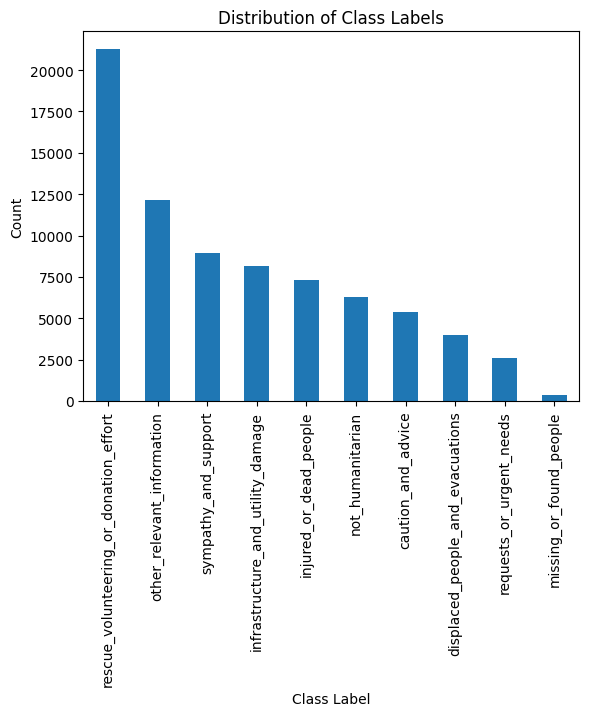

In [33]:
df['class_label'].value_counts().plot(kind='bar')
plt.title('Distribution of Class Labels')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.show()

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76484 entries, 0 to 76483
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   tweet_text   76484 non-null  str  
 1   class_label  76484 non-null  str  
dtypes: str(2)
memory usage: 13.6 MB


In [30]:
df[df['class_label'].isnull()]

,tweet_text,class_label


In [31]:
df.isnull().sum()

tweet_text     0
class_label    0
dtype: int64

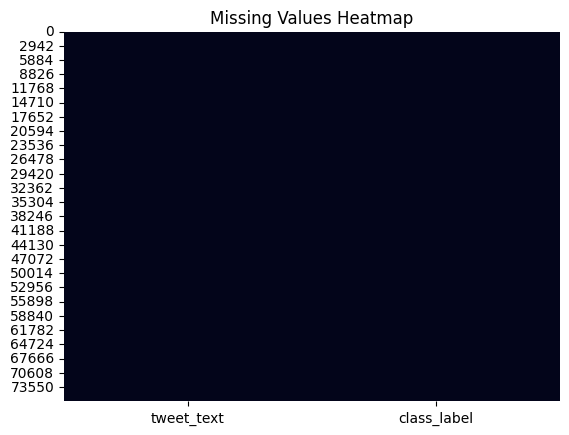

In [34]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [36]:
duplicqates = df.duplicated().sum()
print("duplicqates:", duplicqates)

duplicqates: 6


In [ ]:
df[df.duplicated(subset=['tweet_text'], keep=False)] # duplicates in column tweet_text.

,tweet_text,class_label
22478,Keep these in your prayers tonight: - Earthqua...,sympathy_and_support
24842,Lady Gaga will be donating $1M to relief effor...,rescue_volunteering_or_donation_effort
24987,RT @landovela1: Pray for Mexico they just had ...,sympathy_and_support
25206,RT @MerrellTwins: Our thoughts &amp; prayers a...,sympathy_and_support
59504,RT @MLB: MLB to donate $1 million to assist co...,rescue_volunteering_or_donation_effort
60566,RT @MLB: MLB to donate $1 million to assist co...,rescue_volunteering_or_donation_effort
71549,RT @cher: We ὤFἿB4 Those Suffering From Devast...,infrastructure_and_utility_damage
71830,RT @landovela1: Pray for Mexico they just had ...,sympathy_and_support
71900,RT @MerrellTwins: Our thoughts &amp; prayers a...,sympathy_and_support
72073,Lady Gaga will be donating $1M to relief effor...,rescue_volunteering_or_donation_effort


In [43]:
df = df.drop_duplicates()

In [ ]:
df.shape #six arity removed which are duplicates

(76478, 2)

#### cleaning noises

In [61]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#\w+", "", text)

    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [63]:
df["clean_text"] = df["tweet_text"].apply(clean_text)

#### length of the tweets

In [64]:
df["text_length"] = df["tweet_text"].apply(len)

In [65]:
df["text_length"].describe()

count    76478.000000
mean       141.600042
std         65.519280
min         11.000000
25%         96.000000
50%        125.000000
75%        179.000000
max        959.000000
Name: text_length, dtype: float64

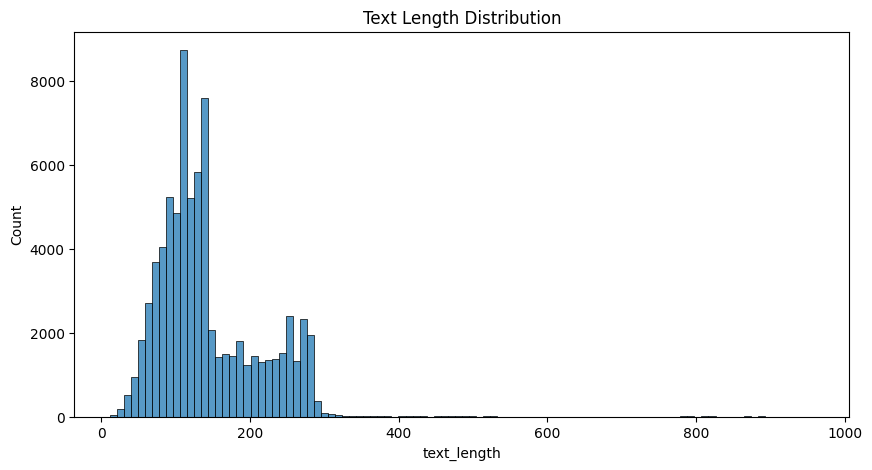

In [67]:
plt.figure(figsize=(10,5))

sns.histplot(df["text_length"], bins=100)

plt.title("Text Length Distribution")

plt.show()

In [68]:
df.head()

,tweet_text,class_label,text_length,clean_text
0,Powerful Ecuador quake kills at least 235: POR...,injured_or_dead_people,110,powerful ecuador quake kills at least 235 port...
1,Im at awe and saddened with the #EcuadorEarthq...,rescue_volunteering_or_donation_effort,102,im at awe and saddened with the please any don...
2,RT @RachelAndJun: Our hearts are with everyone...,sympathy_and_support,138,rt our hearts are with everyone in kumamoto an...
3,RT @noticias2000: Ecuador quake death toll has...,injured_or_dead_people,109,rt ecuador quake death toll has risen to 233 c...
4,RT @pzf: BREAKING PHOTOS: Major damage reporte...,infrastructure_and_utility_damage,84,rt breaking photos major damage reported in ec...


In [71]:
all_words = " ".join(df["clean_text"]).split()

In [ ]:
common_words = Counter(all_words).most_common

In [73]:
common_words

[('the', 56410),
 ('to', 50437),
 ('in', 38159),
 ('of', 33575),
 ('and', 30767),
 ('for', 23146),
 ('a', 19635),
 ('is', 16167),
 ('hurricane', 15614),
 ('are', 13148),
 ('rt', 11698),
 ('by', 11406),
 ('help', 10632),
 ('from', 10266),
 ('you', 10063),
 ('on', 9899),
 ('with', 9510),
 ('people', 8846),
 ('this', 8832),
 ('as', 8190),
 ('at', 8004),
 ('amp', 7877),
 ('relief', 7696),
 ('have', 7191),
 ('our', 7085),
 ('we', 7067),
 ('all', 6793),
 ('that', 6745),
 ('be', 6460),
 ('has', 5684),
 ('i', 5587),
 ('will', 5565),
 ('damage', 5561),
 ('victims', 5449),
 ('affected', 5415),
 ('california', 5103),
 ('it', 5078),
 ('please', 4859),
 ('more', 4839),
 ('flood', 4808),
 ('can', 4719),
 ('after', 4649),
 ('water', 4450),
 ('those', 4372),
 ('earthquake', 4368),
 ('my', 4361),
 ('your', 4321),
 ('out', 4103),
 ('kerala', 4065),
 ('if', 3893),
 ('now', 3842),
 ('not', 3842),
 ('need', 3840),
 ('us', 3745),
 ('irma', 3737),
 ('donate', 3723),
 ('who', 3621),
 ('their', 3614),
 ('flood

In [74]:
from wordcloud import WordCloud

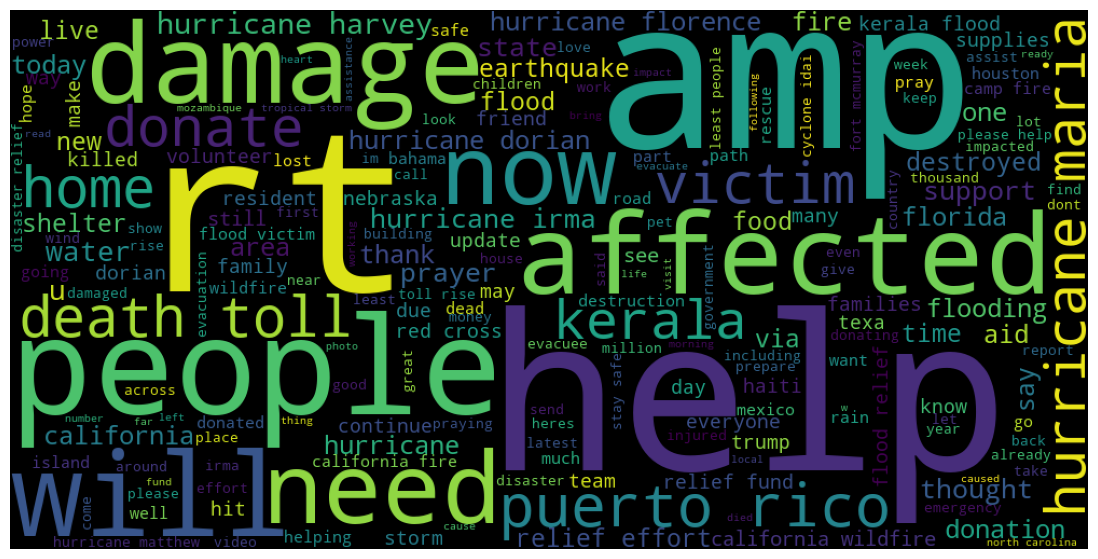

: 

In [ ]:
text = " ".join(df["clean_text"])

wordcloud = WordCloud(
    width=1000,
    height=500
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()